# RNN Language Modeling

This notebook demonstrates a compact word-level RNN/LSTM workflow: corpus preparation, vocabulary, batching, training and text generation.

In [1]:
import re
import math
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


##В качестве произведение выбраны "Письма Баламута"

In [2]:
import requests

url = "https://www.lib.ru/TALES/LEWIS_C_S/screwtape.txt"
text = requests.get(url).text[1209:]

print(text[:2000])
print("Total characters:", len(text))

<ul><a name=1></a><h2>ВСТУПЛЕНИЕ</h2></ul>
 Я не собираюсь объяснять, как в мои руки попала та переписка, которую я
теперь предлагаю вниманию общества.
 Есть два равносильных и противоположных заблуждения относительно бесов.
Одни не верят в них, другие верят и питают к ним ненужный и нездоровый
интерес. Сами бесы рады обеим ошибкам и с одинаковым восторгом приветствуют
и материалиста, и любителя черной магии.
 Советую моим читателям помнить, что дьявол -- отец лжи и не все, что
говорит Баламут, следует считать правдой, даже с его собственной точки
зрения.
 Я не устанавливал личности тех, кто упомянут в письмах. Однако не
думаю, что, например, отец Игл или мать подопечного описаны достоверно. В
аду, как и на земле, умеют подкрашивать мысли в угоду своим намерениям.
 В заключение должен добавить, что я не пытался уточнить хронологию
писем. Мне кажется, что чаще всего дьявольский принцип датировки никак не
связан с земным временем, и потому я не стал его воспроизводить. История
второй мир

Я не исполюзую текста с сайта гутенберг поэтому все будет в коментариях тут

In [3]:
# def strip_gutenberg_header_footer(text: str) -> str:
# start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK"
# end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK"

# start_idx = text.find(start_marker)
# end_idx = text.find(end_marker)

# if start_idx != -1:
# text = text[start_idx:]
# first_newline = text.find("\n")
# text = text[first_newline + 1:]
# if end_idx != -1:
# text = text[:end_idx]
# return text
# text = strip_gutenberg_header_footer(text)

text = text.lower()

# Простая токенизация: слова + знаки препинания
tokens = re.findall(r"[А-Яа-я]+(?:'[А-Яа-я]+)?", text, re.UNICODE)

print(tokens[:50])
print("Number of tokens:", len(tokens))
print("Number of unique raw tokens:", len(set(tokens)))

['вступление', 'я', 'не', 'собираюсь', 'объяснять', 'как', 'в', 'мои', 'руки', 'попала', 'та', 'переписка', 'которую', 'я', 'теперь', 'предлагаю', 'вниманию', 'общества', 'есть', 'два', 'равносильных', 'и', 'противоположных', 'заблуждения', 'относительно', 'бесов', 'одни', 'не', 'верят', 'в', 'них', 'другие', 'верят', 'и', 'питают', 'к', 'ним', 'ненужный', 'и', 'нездоровый', 'интерес', 'сами', 'бесы', 'рады', 'обеим', 'ошибкам', 'и', 'с', 'одинаковым', 'восторгом']
Number of tokens: 24189
Number of unique raw tokens: 7265


In [4]:
MAX_TOKENS = 500_000 # можно увеличить до 100_000 или больше
MAX_VOCAB = 7000

tokens = tokens[:MAX_TOKENS]
print("Using tokens:", len(tokens))

counter = Counter(tokens)
most_common = counter.most_common(MAX_VOCAB - 2) # reserving <pad>, <unk>

itos = ["<pad>", "<unk>"] + [w for w, _ in most_common]
stoi = {w: i for i, w in enumerate(itos)}

PAD_ID = stoi["<pad>"]
UNK_ID = stoi["<unk>"]

def encode_token(tok):
 return stoi.get(tok, UNK_ID)

ids = [encode_token(tok) for tok in tokens]

print("Vocab size:", len(itos))
print("First 30 ids:", ids[:30])

Using tokens: 24189
Vocab size: 7000
First 30 ids: [2146, 18, 5, 848, 2147, 9, 3, 378, 849, 2148, 183, 2149, 120, 18, 88, 1189, 2150, 850, 60, 525, 2151, 2, 2152, 2153, 2154, 1190, 1191, 5, 635, 3]


In [5]:
SEQ_LEN = 30
TRAIN_FRAC = 0.9
BATCH_SIZE = 16

class LanguageModelingDataset(Dataset):
 def __init__(self, ids, seq_len):
 self.ids = ids
 self.seq_len = seq_len

 def __len__(self):
 return len(self.ids) - self.seq_len

 def __getitem__(self, idx):
 x = torch.tensor(self.ids[idx: idx + self.seq_len], dtype=torch.long)
 y = torch.tensor(self.ids[idx + 1: idx + self.seq_len + 1], dtype=torch.long)
 return x, y

split_idx = int(len(ids) * TRAIN_FRAC)
train_ids = ids[:split_idx]
test_ids = ids[split_idx:]

train_dataset = LanguageModelingDataset(train_ids, SEQ_LEN)
test_dataset = LanguageModelingDataset(test_ids, SEQ_LEN)

train_loader = DataLoader(
 train_dataset,
 batch_size=BATCH_SIZE,
 shuffle=True,
 drop_last=True
)

test_loader = DataLoader(
 test_dataset,
 batch_size=BATCH_SIZE,
 shuffle=False,
 drop_last=False
)

print("Train tokens:", len(train_ids))
print("Test tokens:", len(test_ids))
print("Train examples:", len(train_dataset))
print("Test examples:", len(test_dataset))

xb, yb = next(iter(train_loader))
print("xb shape:", xb.shape)
print("yb shape:", yb.shape)

Train tokens: 21770
Test tokens: 2419
Train examples: 21740
Test examples: 2389
xb shape: torch.Size([16, 30])
yb shape: torch.Size([16, 30])


## Shapes in the model

- input ids: `(batch_size, seq_len)`
- embeddings: `(batch_size, seq_len, emb_dim)`
- RNN hidden states: `(batch_size, seq_len, hidden_dim)`
- output logits: `(batch_size, seq_len, vocab_size)`

На каждом шаге модель предсказывает распределение по всему словарю.

In [6]:
class WordRNN(nn.Module):
 def __init__(self, vocab_size, emb_dim, hidden_dim):
 super().__init__()
 self.emb = nn.Embedding(vocab_size, emb_dim)
 self.rnn = nn.RNN(
 input_size=emb_dim,
 hidden_size=hidden_dim,
 batch_first=True
 )
 self.out = nn.Linear(hidden_dim, vocab_size)

 def forward(self, x, h0=None):
 # x: (B, L)
 x = self.emb(x) # (B, L, E)
 h, h_n = self.rnn(x, h0) # h: (B, L, H)
 logits = self.out(h) # (B, L, V)
 return logits, h_n

In [7]:
VOCAB_SIZE = len(itos)
EMB_DIM = 16
HIDDEN_DIM = 16

model = WordRNN(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM).to(device)
model

WordRNN(
 (emb): Embedding(7000, 16)
 (rnn): RNN(16, 16, batch_first=True)
 (out): Linear(in_features=16, out_features=7000, bias=True)
)

###Если нужна LSTM модель вместо RNN, то запустите следующие 2 блока


In [43]:
class WordLSTM(nn.Module):
 def __init__(self, vocab_size, emb_dim, hidden_dim):
 super().__init__()
 self.emb = nn.Embedding(vocab_size, emb_dim)
 self.rnn = nn.LSTM(
 input_size=emb_dim,
 hidden_size=hidden_dim,
 batch_first=True
 )
 self.out = nn.Linear(hidden_dim, vocab_size)

 def forward(self, x, state=None):
 x = self.emb(x)
 h, state = self.rnn(x, state)
 logits = self.out(h)
 return logits, state

In [44]:
VOCAB_SIZE = len(itos)
EMB_DIM = 16
HIDDEN_DIM = 16

model = WordLSTM(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM).to(device)
model

WordLSTM(
 (emb): Embedding(7000, 64)
 (rnn): LSTM(64, 64, batch_first=True)
 (out): Linear(in_features=64, out_features=7000, bias=True)
)

###Меняя значение lr можно поменять шаг в градиентном стахостическом спуске

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

In [9]:
@torch.no_grad()
def evaluate(model, loader, criterion, device, vocab_size):
 model.eval()
 total_loss = 0.0
 total_batches = 0

 for xb, yb in loader:
 xb = xb.to(device)
 yb = yb.to(device)

 logits, _ = model(xb)
 loss = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1))

 total_loss += loss.item()
 total_batches += 1

 mean_loss = total_loss / total_batches
 ppl = math.exp(mean_loss)
 return mean_loss, ppl


EPOCHS = 13

train_losses = []
test_losses = []
train_ppls = []
test_ppls = []

for epoch in range(EPOCHS):
 model.train()
 running_loss = 0.0

 for xb, yb in train_loader:
 xb = xb.to(device)
 yb = yb.to(device)

 optimizer.zero_grad()
 logits, _ = model(xb)
 loss = criterion(logits.reshape(-1, VOCAB_SIZE), yb.reshape(-1))
 loss.backward()
 optimizer.step()

 running_loss += loss.item()

 train_loss = running_loss / len(train_loader)
 train_ppl = math.exp(train_loss)

 test_loss, test_ppl = evaluate(model, test_loader, criterion, device, VOCAB_SIZE)

 train_losses.append(train_loss)
 test_losses.append(test_loss)
 train_ppls.append(train_ppl)
 test_ppls.append(test_ppl)

 print(
 f"Epoch {epoch+1}/{EPOCHS} | "
 f"train loss = {train_loss:.4f} | train ppl = {train_ppl:.2f} | "
 f"test loss = {test_loss:.4f} | test ppl = {test_ppl:.2f}"
 )

Epoch 1/13 | train loss = 8.8739 | train ppl = 7142.76 | test loss = 8.8643 | test ppl = 7074.93
Epoch 2/13 | train loss = 8.8380 | train ppl = 6891.37 | test loss = 8.8435 | test ppl = 6928.99
Epoch 3/13 | train loss = 8.7967 | train ppl = 6612.14 | test loss = 8.8182 | test ppl = 6755.80
Epoch 4/13 | train loss = 8.7451 | train ppl = 6280.14 | test loss = 8.7848 | test ppl = 6534.33
Epoch 5/13 | train loss = 8.6772 | train ppl = 5867.64 | test loss = 8.7386 | test ppl = 6239.01
Epoch 6/13 | train loss = 8.5869 | train ppl = 5360.91 | test loss = 8.6764 | test ppl = 5862.75
Epoch 7/13 | train loss = 8.4746 | train ppl = 4791.59 | test loss = 8.6004 | test ppl = 5433.91
Epoch 8/13 | train loss = 8.3520 | train ppl = 4238.57 | test loss = 8.5190 | test ppl = 5008.90
Epoch 9/13 | train loss = 8.2304 | train ppl = 3753.15 | test loss = 8.4386 | test ppl = 4621.92
Epoch 10/13 | train loss = 8.1144 | train ppl = 3342.26 | test loss = 8.3628 | test ppl = 4284.75
Epoch 11/13 | train loss = 8.

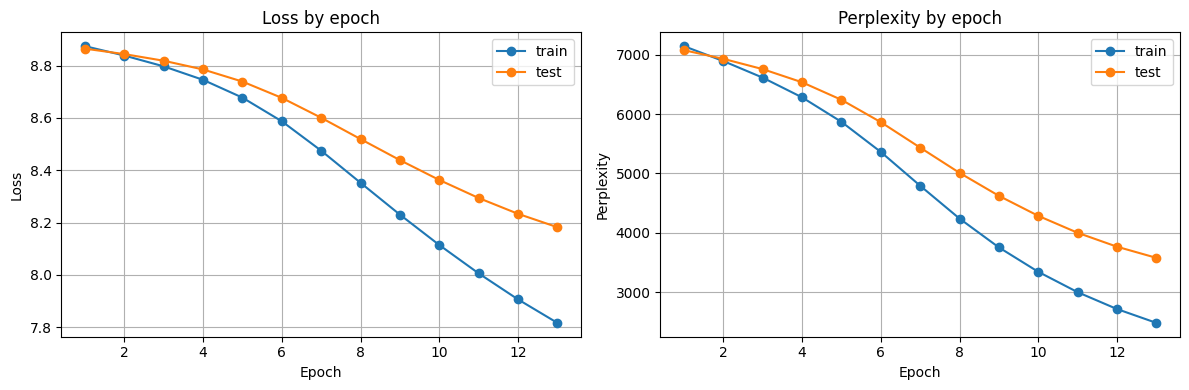

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(train_losses) + 1), train_losses, marker="o", label="train")
axes[0].plot(range(1, len(test_losses) + 1), test_losses, marker="o", label="test")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss by epoch")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(range(1, len(train_ppls) + 1), train_ppls, marker="o", label="train")
axes[1].plot(range(1, len(test_ppls) + 1), test_ppls, marker="o", label="test")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Perplexity")
axes[1].set_title("Perplexity by epoch")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
def decode_ids(id_list):
 return " ".join(itos[i] for i in id_list)

def sample_from_logits(logits, method="greedy", temperature=1.0, top_k=None):
 """
 logits: tensor of shape (V,)
 """
 logits = logits.detach().cpu()

 if method == "greedy":
 return int(torch.argmax(logits).item())

 # temperature
 logits = logits / temperature

 # top-k
 if top_k is not None:
 values, indices = torch.topk(logits, k=min(top_k, logits.shape[0]))
 probs = torch.softmax(values, dim=0)
 chosen = torch.multinomial(probs, num_samples=1).item()
 return int(indices[chosen].item())

 # plain sampling
 probs = torch.softmax(logits, dim=0)
 return int(torch.multinomial(probs, num_samples=1).item())

In [12]:
@torch.no_grad()
def generate_text(
 model,
 prompt,
 max_new_tokens=30,
 method="greedy",
 temperature=1.0,
 top_k=None
):
 model.eval()

 prompt_tokens = re.findall(r"[А-Яа-я]+(?:'[А-Яа-я]+)?", prompt.lower(), re.UNICODE)
 if len(prompt_tokens) == 0:
 raise ValueError("Prompt is empty after tokenization.")

 input_ids = [stoi.get(tok, UNK_ID) for tok in prompt_tokens]
 generated = input_ids[:]

 # Сначала прогоняем весь prompt, чтобы получить состояние
 x = torch.tensor([generated], dtype=torch.long, device=device)
 logits, h = model(x)

 # Последний логит соответствует предсказанию после последнего токена prompt
 next_logits = logits[0, -1]

 for _ in range(max_new_tokens):
 next_id = sample_from_logits(
 next_logits,
 method=method,
 temperature=temperature,
 top_k=top_k
 )
 generated.append(next_id)

 # Следующий шаг: подаём только последний токен и продолжаем с тем же hidden state
 x_next = torch.tensor([[next_id]], dtype=torch.long, device=device)
 logits, h = model(x_next, h)
 next_logits = logits[0, -1]

 return decode_ids(generated)

In [13]:
prompt = "он мог"
print(generate_text(model, prompt, max_new_tokens=40, method="greedy"))

он мог и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и


In [14]:
prompt = "враг знает"
print(generate_text(model, prompt, max_new_tokens=40, method="sampling"))

враг знает принадлежит спускаются актрис пришло соседних сейчас нового молитв конкуренции ресторан напечатанных сторону спасать строк высказываниях люд событий стала готов поймет ест уделять на смелых костюмах вечера плохое окончательный слову наказание теряю страха отказался при дураков инъекция юмора во уверяют оказывает


In [15]:
prompt = "он уже сомневается"
print(generate_text(model, prompt, max_new_tokens=40, method="sampling"))

он уже <unk> восхитительных качествам справиться признают забуду склонности направлений из унижая ко ничтожеств потертом недостаток крючок тиран яйцо двойственны дам отдавших говоришь христиане ее настоящий олей баламут эффективны побродит помнить подстегнуть книжечку роль мужества пуст ему подсовывая знакомых подрывать застой довольство сможем


In [16]:
prompt = "укрепи веру"
print(generate_text(model, prompt, max_new_tokens=40, method="sampling", top_k=10))

укрепи веру в как то и то на на то он он не то он в не от не то он как он в все и на от то от на в мы все на в не как он как что все


##Выводы
Я долго игрался с гипер параметрами и пришел к следующим выводам:
1. Текст очень маленький, 25000 токенов не достаточно
2. С более меньшим шагом сдвига лучше работает, при большем значении переменной lr в torch.optim.Adam()
3. Bash, Emb, Hidden я сделал маленькими чтобы модель проходила больше эпох. Лучше чтобы скрытый слой был не больше слой с ембедингами, я не знаю почему но при другом случае у меня ppl с 1-ой же эпохи начинал расти. При одинаковых значениях bash и Emb модель обучалась быстрее и тратила меньше эпох.